# Comparison: Elliptical Grip vs. Learnable Complex Polynomial Mapping

This notebook compares two initial mapping strategies for the Neural Form-Finding pipeline:

1. **Elliptical Grip** — a fixed analytic mapping (Shirley-Chiu disk projection). Only a global scale and translation are learnable. Serves as a baseline.
2. **Learnable Asymmetric-Roots Polynomial** — a differentiable complex polynomial mapping parameterised by roots and weights. Rich expressivity, fully optimised end-to-end.

Six physical protocols from `data/configs/poster/` are used. Each protocol defines identical boundary conditions and loads; only the mapping strategy differs.

## 0. Environment Setup

In [84]:
import os
import sys
import pickle
import numpy as np
from pathlib import Path

os.environ["JAX_PLATFORM_NAME"] = "cpu"

# Walk upward from cwd until we find train.py + src/
def _find_repo_root() -> Path:
    for candidate in [Path(os.getcwd())] + list(Path(os.getcwd()).parents):
        if (candidate / 'train.py').exists() and (candidate / 'src').is_dir():
            return candidate
    raise RuntimeError(f"Could not find repo root from {os.getcwd()!r}")

REPO_ROOT = _find_repo_root()
SRC_PATH  = str(REPO_ROOT / 'src')

if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

# Change working directory to repo root
os.chdir(REPO_ROOT)

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

print(f'Repo root : {REPO_ROOT}')
print(f'JAX       : {jax.__version__}  |  backend: {jax.default_backend()}')


Repo root : /Users/julienkloers/Documents/Code2/princeton/neural-form-finding
JAX       : 0.6.2  |  backend: cpu


In [85]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Princeton pipeline style (mirrors pipeline_viz.py / visualization.py)
plt.style.use('default')
plt.rcParams.update({
    'font.family':        'serif',
    'font.serif':         ['Times New Roman', 'DejaVu Serif'],
    'font.size':          10,
    'axes.titlesize':     11,
    'axes.labelsize':     10,
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'legend.fontsize':    9,
    'figure.dpi':         150,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.linewidth':     1.0,
    'axes.grid':          True,
    'grid.linestyle':     '--',
    'grid.alpha':         0.3,
    'grid.color':         '#888888',
    'lines.linewidth':    2.0,
    'figure.facecolor':   '#FFFFFF',
    'axes.facecolor':     '#FFFFFF',
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'savefig.facecolor':  '#FFFFFF',
})

# Pipeline colour palette
COLORS = {
    'elliptical': 'black',   # steel blue  (hinge colour in pipeline)
    'complex':    '#F58025',   # Princeton orange (primary method)
}
LW = {
    'elliptical': 2.0,
    'complex':    2.5,
}
LABELS = {
    'elliptical': 'Elliptical Grip (baseline)',
    'complex':    'Complex Polynomial (learned)',
}
# Energy-stack colours (matches pipeline_viz.py stackplot)
STACK_COLORS = ['#F58025', '#FFB380', '#D9D9D9', '#808080']

## 1. Pipeline Imports

In [86]:
from types import SimpleNamespace

from topology.builder import build_tessellation
from problem.conditions import configure_tessellation
from problem.config import load_and_parse_config
from jax_backend.state import CentroidalState
from jax_backend.pipeline import forward_pipeline
from jax_backend.training.trainer import train_pipeline
from jax_backend.geometry import reconstruct_vertices, compute_face_areas
from utils.visualization import plot_tessellation

## 2. Experiment Configuration

In [87]:
N_EXPERIMENTS = 6
EXPERIMENT_IDS = list(range(1, N_EXPERIMENTS + 1))

CONFIG_BASE = os.path.join(REPO_ROOT, 'data', 'configs', 'poster')
CACHE_DIR   = os.path.join(REPO_ROOT, 'data', 'outputs', 'notebook_cache')
FIG_DIR     = os.path.join(REPO_ROOT, 'data', 'outputs', 'notebook_figures')

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(FIG_DIR,   exist_ok=True)

def config_path(method: str, exp_id: int) -> str:
    return os.path.join(CONFIG_BASE, method, f'experience{exp_id}.yaml')

def cache_path(method: str, exp_id: int) -> str:
    return os.path.join(CACHE_DIR, f'{method}_exp{exp_id}.pkl')

# Elliptical-grip map params: only tx, ty, log_scale are learnable
ELLIPTICAL_MAP_PARAMS = {
    'tx':        jnp.array(0.0),
    'ty':        jnp.array(0.0),
    'log_scale': jnp.array(0.0),
}

print(f'Config root : {CONFIG_BASE}')
print(f'Cache dir   : {CACHE_DIR}')
print(f'Figures dir : {FIG_DIR}')

Config root : /Users/julienkloers/Documents/Code2/princeton/neural-form-finding/data/configs/poster
Cache dir   : /Users/julienkloers/Documents/Code2/princeton/neural-form-finding/data/outputs/notebook_cache
Figures dir : /Users/julienkloers/Documents/Code2/princeton/neural-form-finding/data/outputs/notebook_figures


## 3. Training Helper

In [88]:
def run_experiment(method: str, exp_id: int, force_rerun: bool = False) -> dict:
    """Run one (method, experiment) pair and return results dict.
    
    Results are cached to disk; set force_rerun=True to ignore the cache.
    """
    pkl = cache_path(method, exp_id)
    if not force_rerun and os.path.exists(pkl):
        print(f'  [{method}] exp{exp_id}: loading from cache')
        with open(pkl, 'rb') as f:
            return pickle.load(f)

    print(f'\n  [{method}] exp{exp_id}: training ...')

    # Always load from the 'complex' folder (identical physics); override map if needed.
    cfg_file = config_path('complex', exp_id)
    config   = load_and_parse_config(cfg_file)

    # Build tessellation
    topo = config.topology
    tessellation = build_tessellation(
        topo.get('pattern'),
        topo.get('width',  5),
        topo.get('height', 5),
    )
    requested_area = topo.get('total_area')
    if requested_area:
        import numpy as np_
        scale = np_.sqrt(requested_area / tessellation.compute_total_area())
        tessellation.update_vertices(tessellation.vertices * scale)

    configure_tessellation(tessellation, SimpleNamespace(**topo))
    initial_state = CentroidalState.from_tessellation(tessellation, target_cfg=config.target)

    # Select method-specific settings
    if method == 'elliptical':
        map_type           = 'elliptical_grip'
        initial_params     = ELLIPTICAL_MAP_PARAMS
        learn_global_scale = True
        use_shirley_chiu   = True
    else:  # complex
        map_type           = config.mapping.type
        learn_global_scale = config.mapping.learn_global_scale
        use_shirley_chiu   = config.mapping.use_shirley_chiu
        raw = config.mapping.params
        initial_params = raw if isinstance(raw, dict) else {}
        if learn_global_scale and 'log_scale' not in initial_params:
            initial_params = {**initial_params, 'log_scale': jnp.array(0.0)}

    optimized_params, history = train_pipeline(
        initial_params,
        initial_state,
        config.target,
        config.validity,
        config.physics,
        config.training,
        map_type           = map_type,
        use_shirley_chiu   = use_shirley_chiu,
        strict_boundary_fit= config.mapping.strict_boundary_fit,
        learn_global_scale = learn_global_scale,
    )

    # Final forward pass
    result = forward_pipeline(
        initial_state,
        config.target,
        config.validity,
        config.physics,
        map_type           = map_type,
        map_params         = optimized_params,
        use_shirley_chiu   = use_shirley_chiu,
        strict_boundary_fit= config.mapping.strict_boundary_fit,
    )

    # Collect scalar metrics from last epoch
    last = history[-1]
    final_metrics = {
        'chamfer':    float(last['chamfer_total']),
        'energy':     float(last['energy']),
        'stretch':    float(last['comp_phys_stretching']),
        'shear':      float(last['comp_phys_shearing']),
        'bending':    float(last['comp_phys_bending']),
        'contact':    float(last['comp_phys_contact']),
        'total_loss': float(last['total']),
        'area_dev':   float(last['global_material_area']),
    }

    def _to_float(v):
        try:
            return float(v)
        except Exception:
            return None

    history_clean = [{k: _to_float(v) for k, v in ep.items() if not isinstance(v, dict)}
                     for ep in history]

    final_cnvs       = np.array(result['valid_state'].centroid_node_vectors)
    final_centroids  = np.array(result['valid_state'].face_centroids)
    displacements    = np.array(result['solution'].fields[-1])

    # Boundary conditions and loads — needed for visualisation
    bc = topo.get('bc_clamped', [])
    clamped_faces = list(bc) if isinstance(bc, list) else []
    raw_loads = topo.get('loads', [])

    data = {
        'method':          method,
        'exp_id':          exp_id,
        'final_metrics':   final_metrics,
        'history':         history_clean,
        'final_cnvs':      final_cnvs,
        'final_centroids': final_centroids,
        'displacements':   displacements,
        'target':          {'type': config.target.type,
                            'center': list(config.target.center),
                            'radius': float(config.target.radius)},
        'clamped_faces':   clamped_faces,
        'loads':           raw_loads,
    }

    with open(pkl, 'wb') as f:
        pickle.dump(data, f)
    print(f'  [{method}] exp{exp_id}: done. Total loss = {final_metrics["total_loss"]:.4e}')
    return data

## 4. Run All Experiments

Set `FORCE_RERUN = True` to ignore the cache and retrain from scratch.

In [89]:
FORCE_RERUN = False  # Set True to re-train

results = {}  # (method, exp_id) -> data dict

for method in ['elliptical', 'complex']:
    for exp_id in EXPERIMENT_IDS:
        key = (method, exp_id)
        results[key] = run_experiment(method, exp_id, force_rerun=FORCE_RERUN)

print('\nAll experiments complete.')

  [elliptical] exp1: loading from cache
  [elliptical] exp2: loading from cache
  [elliptical] exp3: loading from cache
  [elliptical] exp4: loading from cache
  [elliptical] exp5: loading from cache
  [elliptical] exp6: loading from cache
  [complex] exp1: loading from cache
  [complex] exp2: loading from cache
  [complex] exp3: loading from cache
  [complex] exp4: loading from cache
  [complex] exp5: loading from cache
  [complex] exp6: loading from cache

All experiments complete.


## 5. Loss Convergence Curves

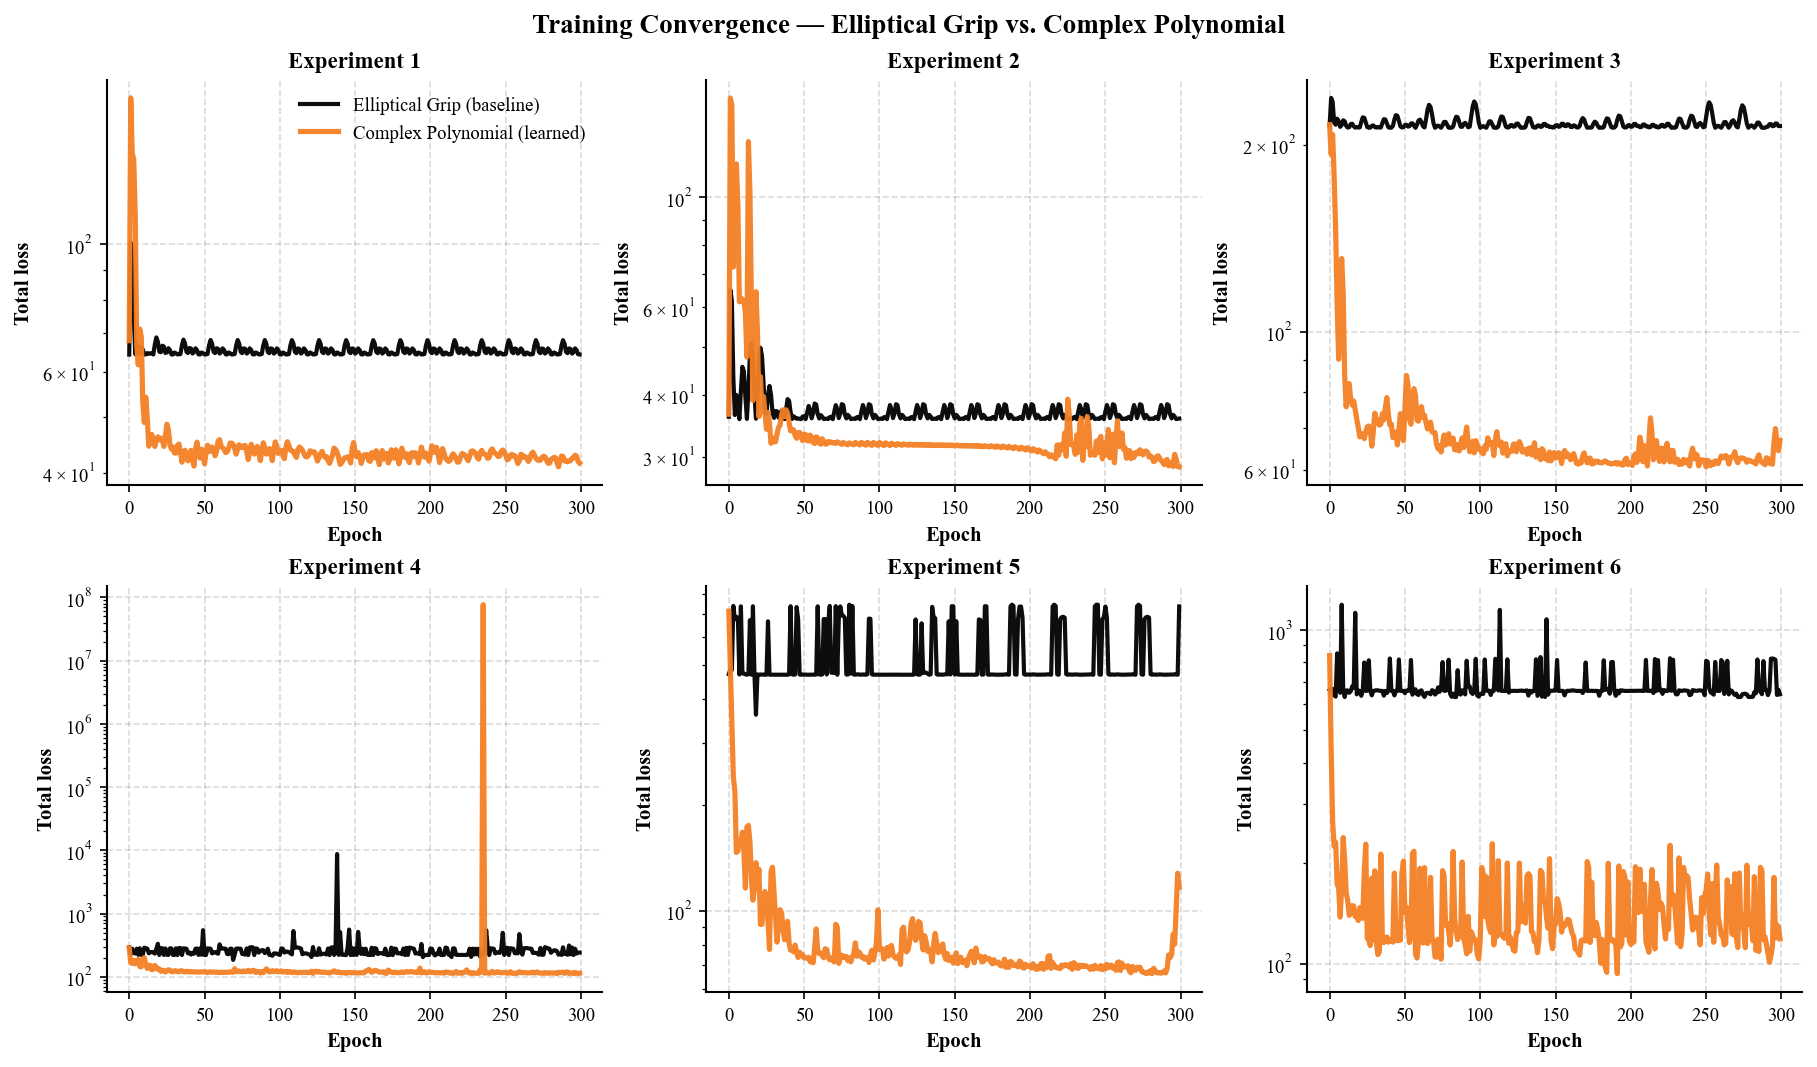

In [90]:
def get_series(data: dict, key: str):
    return [ep.get(key) for ep in data['history'] if ep.get(key) is not None]

fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
axes = axes.flatten()

for i, exp_id in enumerate(EXPERIMENT_IDS):
    ax = axes[i]
    for method in ['elliptical', 'complex']:
        data   = results[(method, exp_id)]
        series = get_series(data, 'total')
        epochs = np.arange(len(series))
        ax.semilogy(epochs, series,
                    color=COLORS[method], lw=LW[method],
                    label=LABELS[method], alpha=0.95)
    ax.set_title(f'Experiment {exp_id}', fontweight='bold')
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('Total loss', fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 0:
        ax.legend(frameon=False)

fig.suptitle('Training Convergence — Elliptical Grip vs. Complex Polynomial',
             fontsize=13, fontweight='bold')
fig.savefig(os.path.join(FIG_DIR, 'convergence_curves.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'convergence_curves.png'))
plt.show()

## 6. Chamfer Distance Comparison

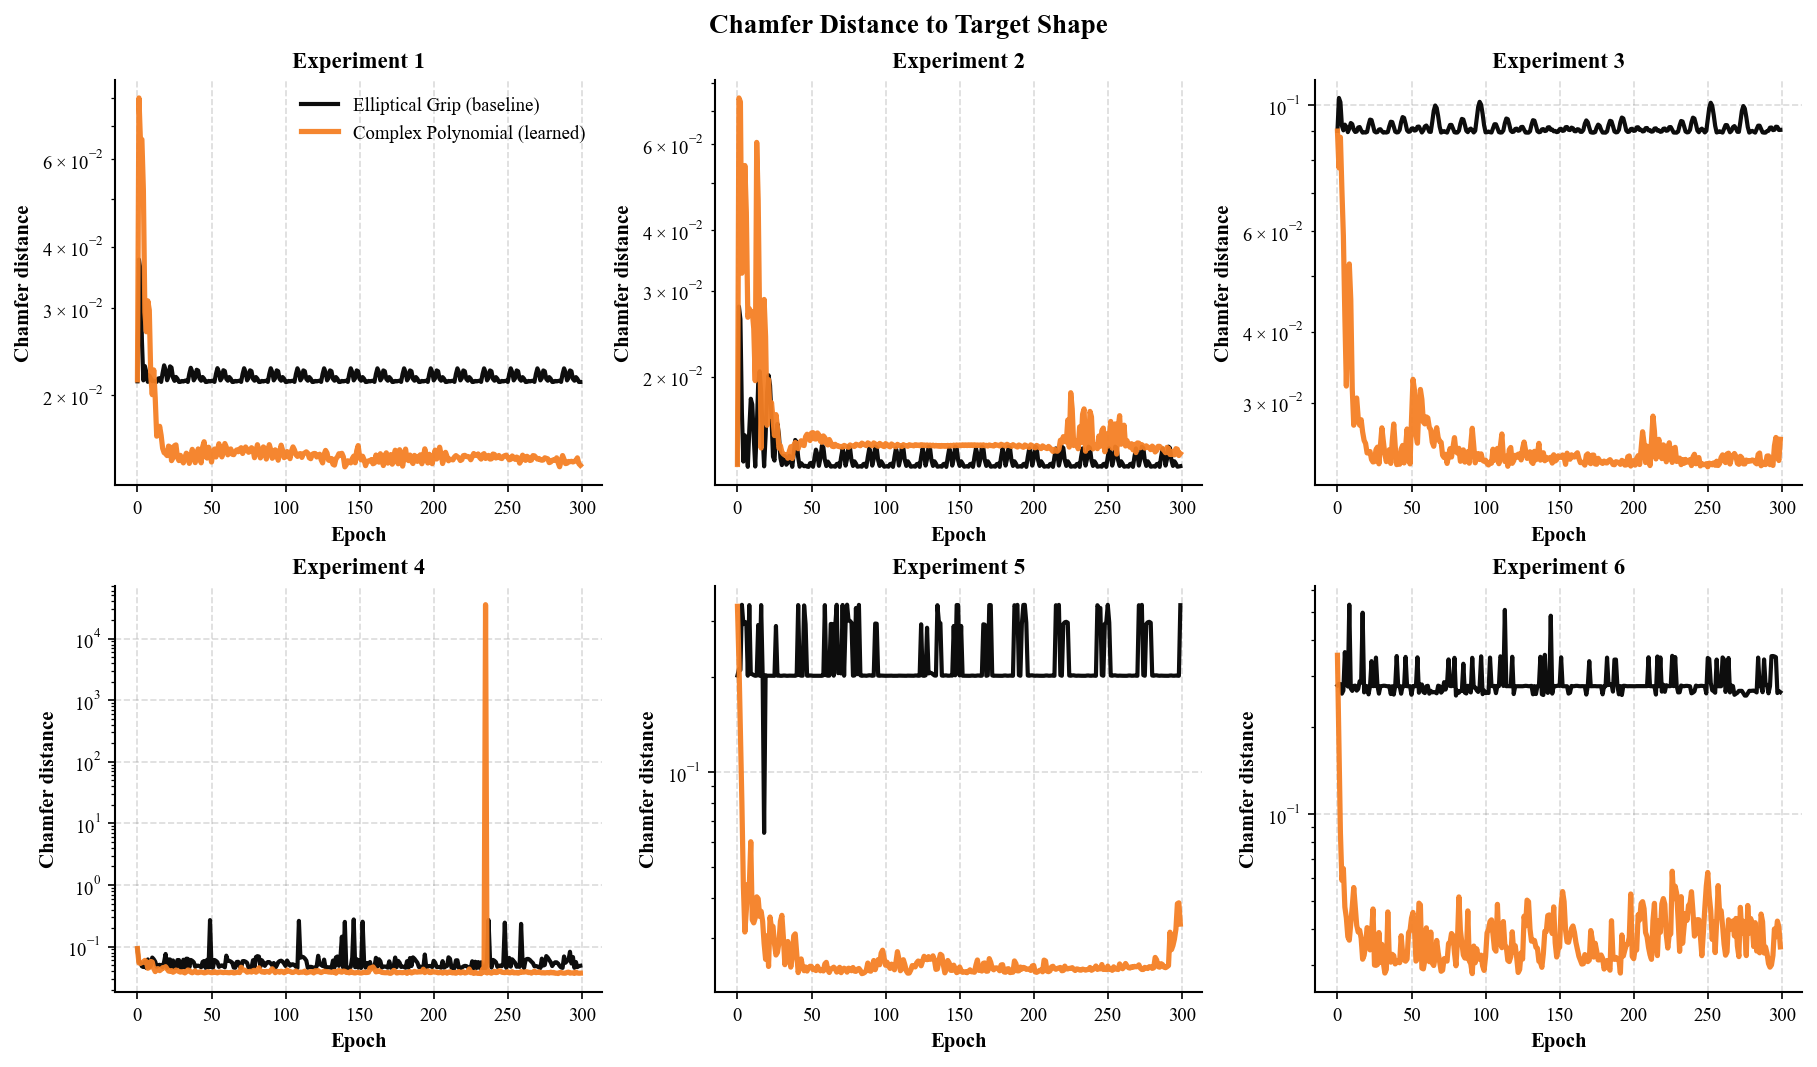

In [91]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
axes = axes.flatten()

for i, exp_id in enumerate(EXPERIMENT_IDS):
    ax = axes[i]
    for method in ['elliptical', 'complex']:
        data   = results[(method, exp_id)]
        series = get_series(data, 'chamfer_total')
        epochs = np.arange(len(series))
        ax.semilogy(epochs, series,
                    color=COLORS[method], lw=LW[method],
                    label=LABELS[method], alpha=0.95)
    ax.set_title(f'Experiment {exp_id}', fontweight='bold')
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('Chamfer distance', fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 0:
        ax.legend(frameon=False)

fig.suptitle('Chamfer Distance to Target Shape', fontsize=13, fontweight='bold')
fig.savefig(os.path.join(FIG_DIR, 'chamfer_curves.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'chamfer_curves.png'))
plt.show()

## 7. Final Metric Bar Charts

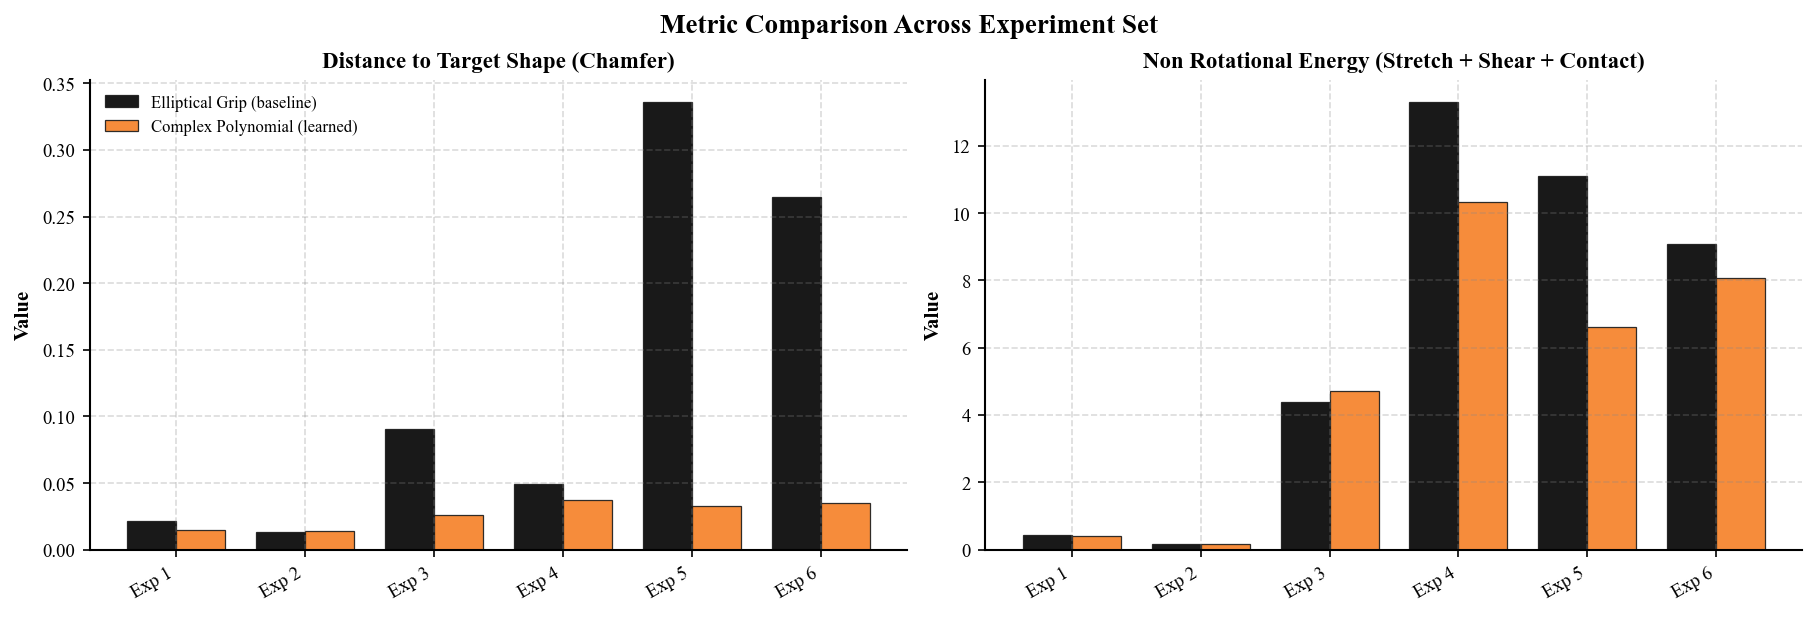

In [92]:
metric_keys   = ['chamfer', 'energy']
metric_labels = ['Distance to Target Shape (Chamfer)', 'Non Rotational Energy (Stretch + Shear + Contact)']

x     = np.arange(N_EXPERIMENTS)
width = 0.38

fig, axes = plt.subplots(1, len(metric_keys), figsize=(12, 4), constrained_layout=True)

for ax, key, label in zip(axes, metric_keys, metric_labels):
    ell_vals = [results[('elliptical', eid)]['final_metrics'][key] for eid in EXPERIMENT_IDS]
    cmp_vals = [results[('complex',    eid)]['final_metrics'][key] for eid in EXPERIMENT_IDS]

    ax.bar(x - width / 2, ell_vals, width,
           color=COLORS['elliptical'], alpha=0.90, label=LABELS['elliptical'],
           edgecolor='#1A1A1A', linewidth=0.6)
    ax.bar(x + width / 2, cmp_vals, width,
           color=COLORS['complex'],    alpha=0.90, label=LABELS['complex'],
           edgecolor='#1A1A1A', linewidth=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels([f'Exp {i}' for i in EXPERIMENT_IDS], rotation=30, ha='right')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Value', fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax is axes[0]:
        ax.legend(frameon=False, loc='upper left', fontsize=8)

fig.suptitle('Metric Comparison Across Experiment Set', fontsize=13, fontweight='bold')
fig.savefig(os.path.join(FIG_DIR, 'bar_metrics.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'bar_metrics.png'))
plt.show()

## 8. Relative Improvement: Complex vs. Elliptical

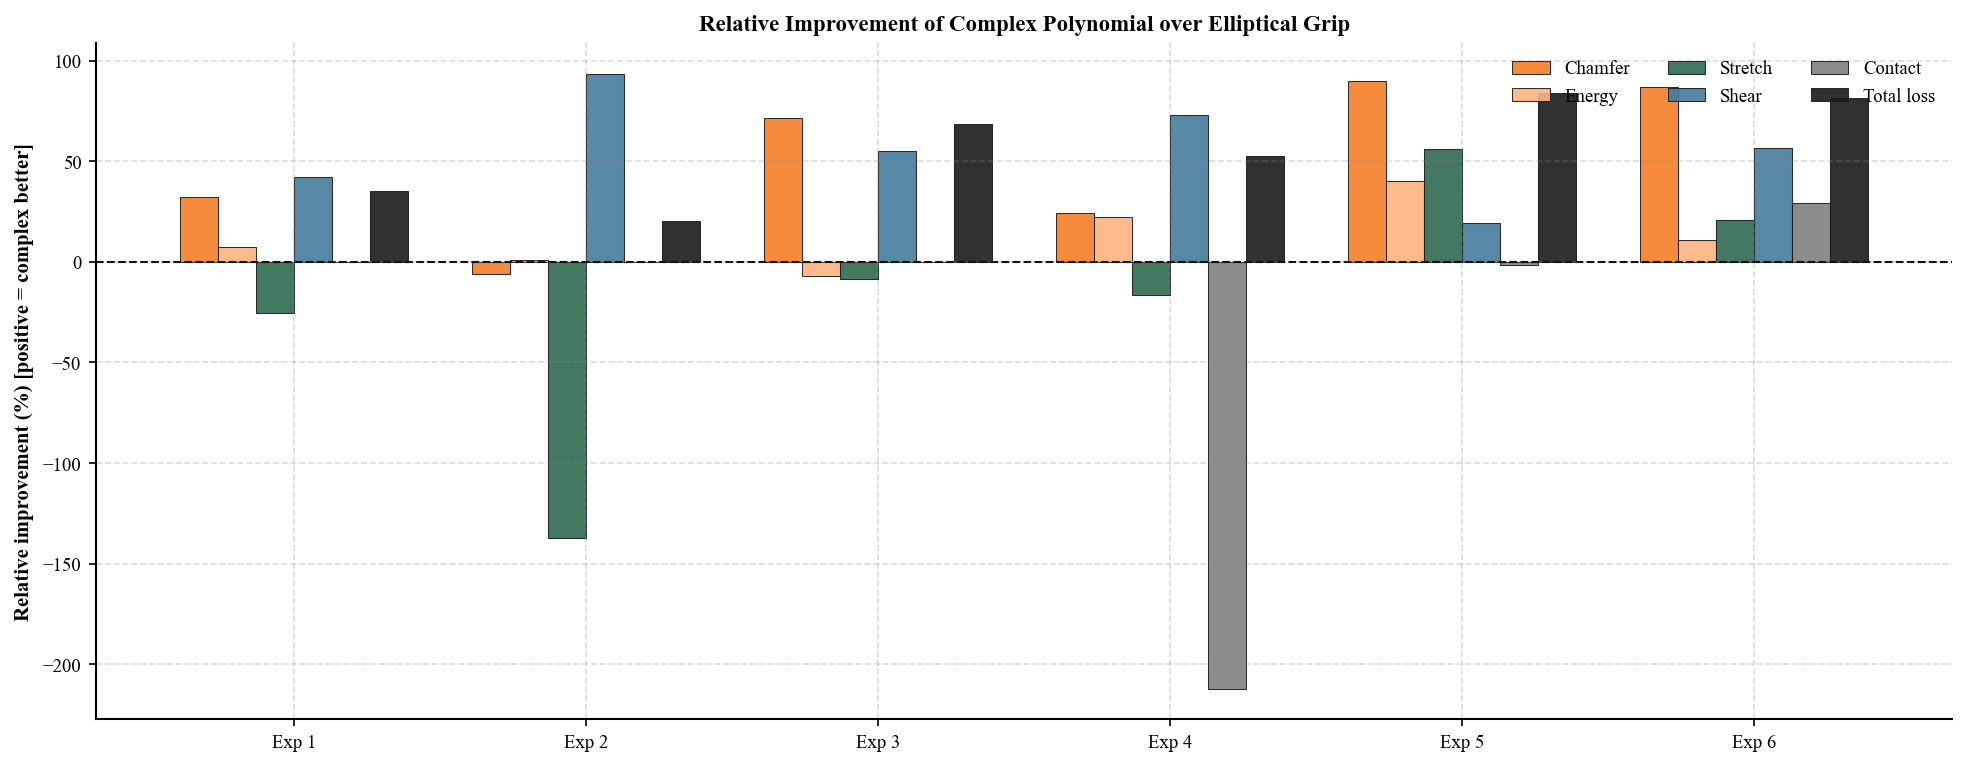

In [93]:
def pct_improvement(ell, cmp):
    """Percentage by which complex is better (lower is better for all metrics)."""
    if abs(ell) < 1e-12:
        return 0.0
    return 100.0 * (ell - cmp) / abs(ell)

compare_keys   = ['chamfer', 'energy', 'stretch', 'shear', 'contact', 'total_loss']
compare_labels = ['Chamfer', 'Energy', 'Stretch', 'Shear', 'Contact', 'Total loss']

# Pipeline-consistent palette for grouped bars
bar_palette = ['#F58025', '#FFB380', '#2D6A4F', '#457B9D', '#808080', '#1A1A1A']

x         = np.arange(N_EXPERIMENTS)
width_bar = 0.13
offsets   = np.linspace(-(len(compare_keys) - 1) / 2,
                         (len(compare_keys) - 1) / 2,
                         len(compare_keys)) * width_bar

fig, ax = plt.subplots(figsize=(13, 5), constrained_layout=True)

for color, key, label, offset in zip(bar_palette, compare_keys, compare_labels, offsets):
    improvements = [
        pct_improvement(
            results[('elliptical', eid)]['final_metrics'][key],
            results[('complex',    eid)]['final_metrics'][key],
        )
        for eid in EXPERIMENT_IDS
    ]
    ax.bar(x + offset, improvements, width_bar,
           color=color, label=label, alpha=0.90,
           edgecolor='#1A1A1A', linewidth=0.5)

ax.axhline(0, color='#111111', linewidth=1.0, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels([f'Exp {i}' for i in EXPERIMENT_IDS])
ax.set_ylabel('Relative improvement (%) [positive = complex better]', fontweight='bold')
ax.set_title('Relative Improvement of Complex Polynomial over Elliptical Grip',
             fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='upper right', ncol=3)

fig.savefig(os.path.join(FIG_DIR, 'relative_improvement.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'relative_improvement.png'))
plt.show()

## 9. Side-by-Side Final Shape Visualisation

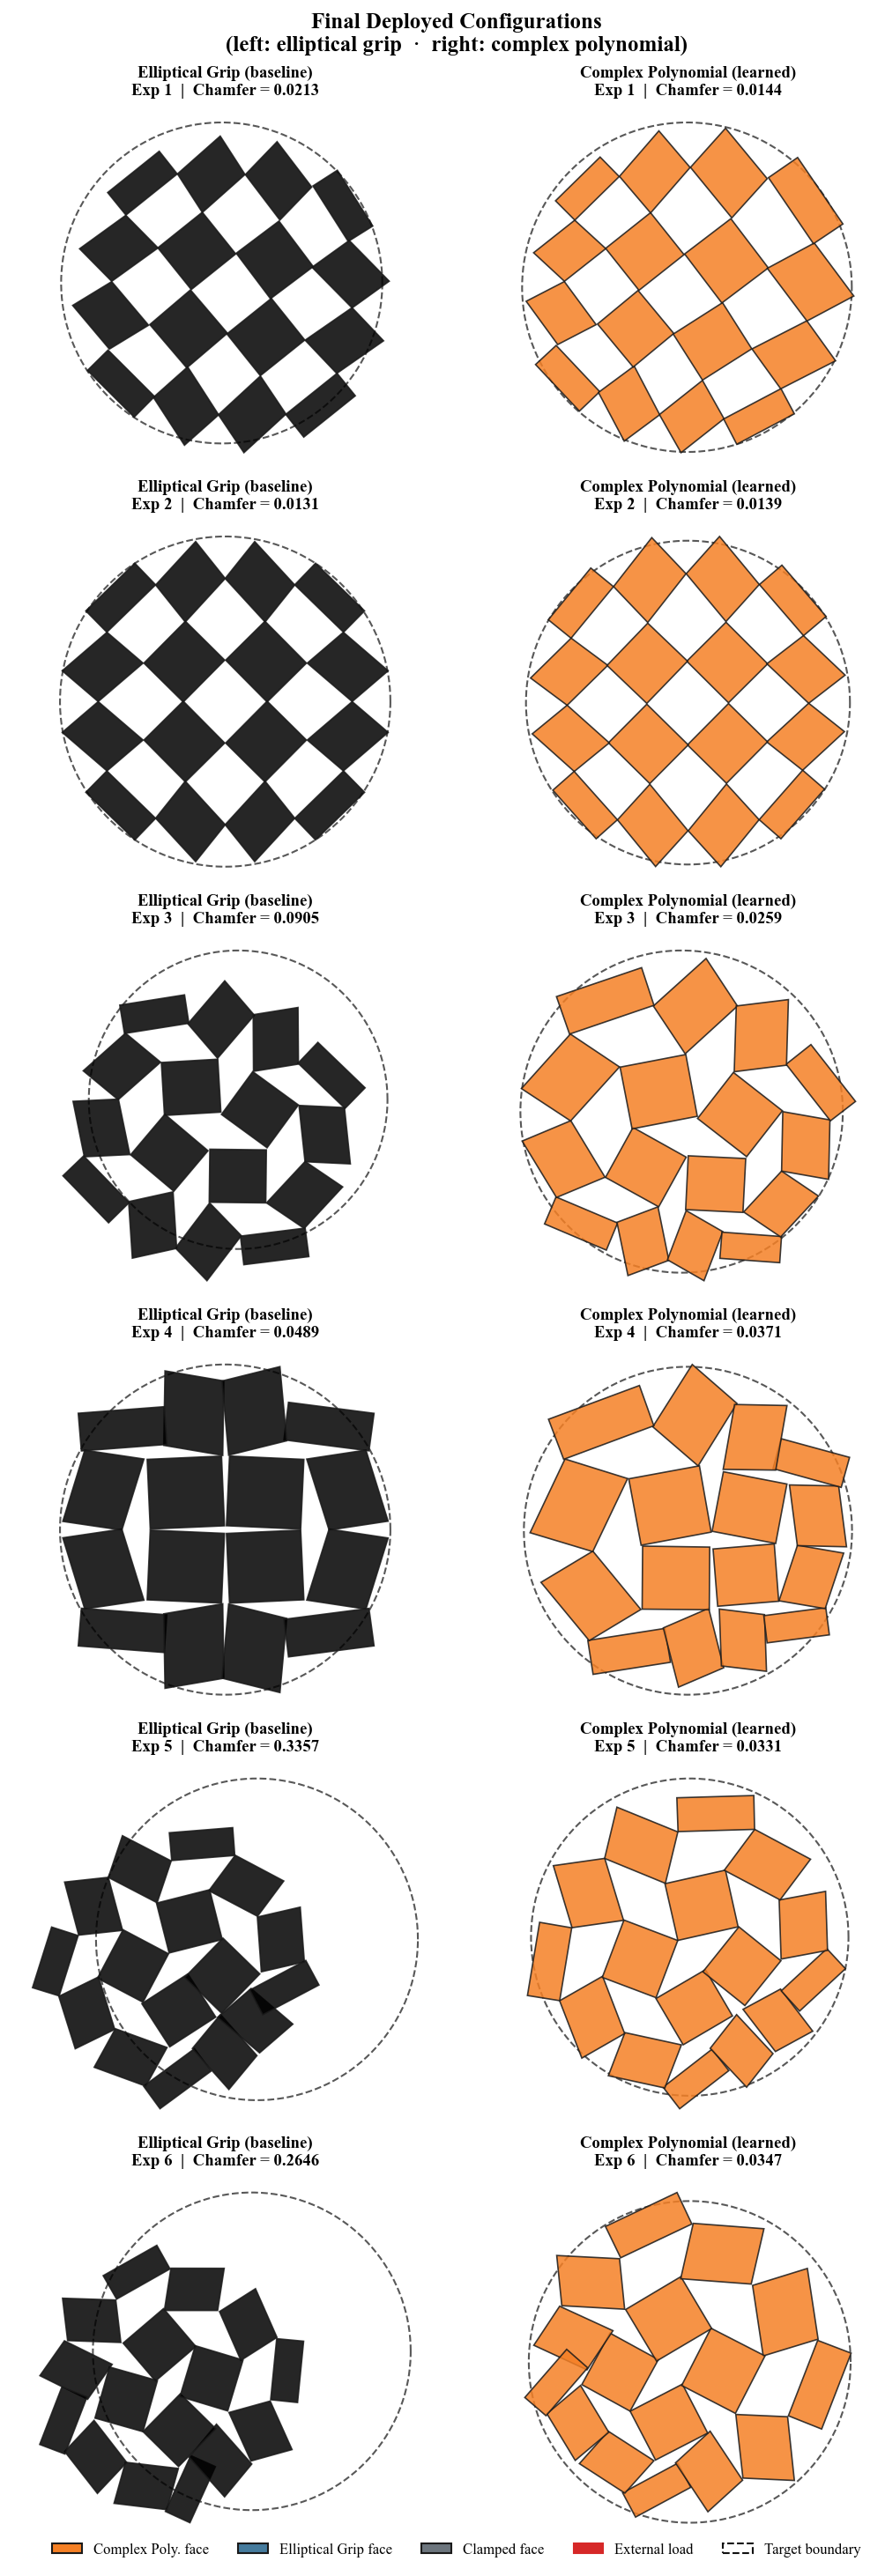

In [94]:
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon, FancyArrowPatch
from matplotlib.collections import PatchCollection

def draw_structure(ax, cnvs, centroids, displacements, target_params,
                   color='#F58025', title='',
                   clamped_faces=None, loads=None):
    """Draw the final deployed structure from cached geometry.

    clamped_faces : list[int] — face indices that are clamped (drawn in gray)
    loads         : list[dict] — load dicts with keys 'face', 'dof', 'value'
    """
    n_faces, max_nodes, _ = cnvs.shape
    clamped_set = set(clamped_faces or [])

    final_centroids = centroids + displacements[:, :2]
    final_thetas    = displacements[:, 2]

    # ── Faces (individual patches for per-face colouring) ────────────────────
    for f in range(n_faces):
        c  = final_centroids[f]
        th = final_thetas[f]
        R  = np.array([[np.cos(th), -np.sin(th)],
                        [np.sin(th),  np.cos(th)]])
        nodes = cnvs[f]
        verts = c + (R @ nodes.T).T
        norms = np.linalg.norm(nodes, axis=1)
        verts = verts[norms > 1e-10]
        if len(verts) < 3:
            continue

        fc = '#6C757D' if f in clamped_set else color
        poly = MplPolygon(verts, closed=True,
                          facecolor=fc, edgecolor='#1A1A1A',
                          linewidth=0.8, alpha=0.85, zorder=10)
        ax.add_patch(poly)

    # ── Forces and moments ───────────────────────────────────────────────────
    for load_entry in (loads or []):
        face_spec = load_entry.get('face', [])
        dof       = load_entry.get('dof', 1)
        value     = float(load_entry.get('value', 0.0))
        if value == 0.0:
            continue

        target_faces = face_spec if isinstance(face_spec, list) else [face_spec]

        for fid in target_faces:
            if fid >= n_faces:
                continue
            cx, cy = final_centroids[fid]

            if dof in (0, 1):
                fx = value if dof == 0 else 0.0
                fy = value if dof == 1 else 0.0
                force_len = np.sqrt(fx**2 + fy**2)
                scale = min(0.2 / force_len, 0.05) if force_len > 0 else 0.05
                ax.arrow(cx, cy, fx * scale, fy * scale,
                         head_width=0.03, head_length=0.03,
                         fc='#D62828', ec='#D62828',
                         width=0.005, zorder=30)

            elif dof == 2:
                r = 0.10
                if value > 0:
                    start = (cx + r, cy - r / 2)
                    end   = (cx - r / 2, cy + r)
                    rad   = 0.6
                else:
                    start = (cx - r, cy - r / 2)
                    end   = (cx + r / 2, cy + r)
                    rad   = -0.6
                arrow = FancyArrowPatch(
                    start, end,
                    connectionstyle=f"arc3,rad={rad}",
                    color='#D62828',
                    arrowstyle="Simple, tail_width=1.5, head_width=6, head_length=8",
                    zorder=30,
                )
                ax.add_patch(arrow)

    # ── Target circle ────────────────────────────────────────────────────────
    if target_params.get('type', 'circle') == 'circle':
        cx_t, cy_t = target_params['center']
        r_t   = target_params['radius']
        theta = np.linspace(0, 2 * np.pi, 300)
        ax.plot(cx_t + r_t * np.cos(theta), cy_t + r_t * np.sin(theta),
                color='#111111', linestyle='--', linewidth=1.0, alpha=0.7)

    ax.set_aspect('equal')
    ax.autoscale_view()
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_facecolor('#FFFFFF')
    ax.set_axis_off()


# ── Legend patches (shared across all panels) ────────────────────────────────
legend_patches = [
    mpatches.Patch(facecolor='#F58025', edgecolor='#1A1A1A', label='Complex Poly. face'),
    mpatches.Patch(facecolor='#457B9D', edgecolor='#1A1A1A', label='Elliptical Grip face'),
    mpatches.Patch(facecolor='#6C757D', edgecolor='#1A1A1A', label='Clamped face'),
    mpatches.Patch(facecolor='#D62828', edgecolor='#D62828', label='External load'),
    mpatches.Patch(facecolor='none',    edgecolor='#111111',
                   linestyle='--', linewidth=1.0, label='Target boundary'),
]

fig, axes = plt.subplots(N_EXPERIMENTS, 2,
                         figsize=(7, 3.2 * N_EXPERIMENTS), constrained_layout=True)
fig.patch.set_facecolor('#FFFFFF')

for i, exp_id in enumerate(EXPERIMENT_IDS):
    for j, method in enumerate(['elliptical', 'complex']):
        ax   = axes[i, j]
        data = results[(method, exp_id)]
        ch   = data['final_metrics']['chamfer']
        title = (f"{LABELS[method]}\n"
                 f"Exp {exp_id}  |  Chamfer = {ch:.4f}")
        draw_structure(
            ax,
            data['final_cnvs'],
            data['final_centroids'],
            data['displacements'],
            data['target'],
            color        = COLORS[method],
            title        = title,
            clamped_faces= data.get('clamped_faces', []),
            loads        = data.get('loads', []),
        )

fig.legend(handles=legend_patches, loc='lower center',
           ncol=len(legend_patches), frameon=False,
           fontsize=8, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('Final Deployed Configurations\n(left: elliptical grip  ·  right: complex polynomial)',
             fontsize=12, fontweight='bold')

fig.savefig(os.path.join(FIG_DIR, 'final_shapes.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'final_shapes.png'))
plt.show()

## 10. Quantitative Summary Table

In [95]:
import pandas as pd

rows = []
for exp_id in EXPERIMENT_IDS:
    ell = results[('elliptical', exp_id)]['final_metrics']
    cmp = results[('complex',    exp_id)]['final_metrics']
    rows.append({
        'Experiment':    exp_id,
        'Method':        'Elliptical',
        'Chamfer':       ell['chamfer'],
        'Total energy':  ell['energy'],
        'Stretch':       ell['stretch'],
        'Shear':         ell['shear'],
        'Contact':       ell['contact'],
        'Total loss':    ell['total_loss'],
    })
    rows.append({
        'Experiment':    exp_id,
        'Method':        'Complex Poly.',
        'Chamfer':       cmp['chamfer'],
        'Total energy':  cmp['energy'],
        'Stretch':       cmp['stretch'],
        'Shear':         cmp['shear'],
        'Contact':       cmp['contact'],
        'Total loss':    cmp['total_loss'],
    })

df = pd.DataFrame(rows).set_index(['Experiment', 'Method'])

float_cols = ['Chamfer', 'Total energy', 'Stretch', 'Shear', 'Contact', 'Total loss']
styled = df.style.format({c: '{:.4e}' for c in float_cols}).highlight_min(
    subset=float_cols, axis=0, props='background-color: #d4edda; color: black;'
)
styled

In [96]:
# Save as CSV and LaTeX
df.to_csv(os.path.join(FIG_DIR, 'summary_table.csv'))

latex = df.to_latex(
    float_format='%.4e',
    caption='Final metric comparison: elliptical grip vs.\ learnable complex polynomial mapping.',
    label='tab:comparison',
    column_format='llrrrrrr',
)
with open(os.path.join(FIG_DIR, 'summary_table.tex'), 'w') as f:
    f.write(latex)

print('LaTeX table saved to', os.path.join(FIG_DIR, 'summary_table.tex'))
print(latex)

LaTeX table saved to /Users/julienkloers/Documents/Code2/princeton/neural-form-finding/data/outputs/notebook_figures/summary_table.tex
\begin{table}
\caption{Final metric comparison: elliptical grip vs.\ learnable complex polynomial mapping.}
\label{tab:comparison}
\begin{tabular}{llrrrrrr}
\toprule
 &  & Chamfer & Total energy & Stretch & Shear & Contact & Total loss \\
Experiment & Method &  &  &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{1} & Elliptical & 2.1296e-02 & 4.3443e-01 & 1.9053e-01 & 2.1472e+01 & 0.0000e+00 & 6.4254e+01 \\
 & Complex Poly. & 1.4447e-02 & 4.0330e-01 & 2.3854e-01 & 1.2429e+01 & 0.0000e+00 & 4.1612e+01 \\
\cline{1-8}
\multirow[t]{2}{*}{2} & Elliptical & 1.3111e-02 & 1.6158e-01 & 6.4004e-02 & 9.5376e+00 & 0.0000e+00 & 3.5823e+01 \\
 & Complex Poly. & 1.3916e-02 & 1.5970e-01 & 1.5199e-01 & 6.1559e-01 & 0.0000e+00 & 2.8628e+01 \\
\cline{1-8}
\multirow[t]{2}{*}{3} & Elliptical & 9.0506e-02 & 4.3932e+00 & 4.3485e-01 & 3.2771e+01 & 0.0000e+00 & 2.1422e+02 \\
 & Compl

## 11. Aggregate Summary (mean ± std over experiments)

In [97]:
summary_rows = []
for method, label in [('elliptical', 'Elliptical Grip'), ('complex', 'Complex Polynomial')]:
    vals = {k: [] for k in ['chamfer', 'energy', 'stretch', 'shear', 'contact', 'total_loss']}
    for eid in EXPERIMENT_IDS:
        m = results[(method, eid)]['final_metrics']
        for k in vals:
            vals[k].append(m[k])
    row = {'Method': label}
    for k, v in vals.items():
        row[k + '_mean'] = np.mean(v)
        row[k + '_std']  = np.std(v)
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows).set_index('Method')
df_summary

,chamfer_mean,chamfer_std,energy_mean,energy_std,stretch_mean,stretch_std,shear_mean,shear_std,contact_mean,contact_std,total_loss_mean,total_loss_std
Method,,,,,,,,,,,,
Elliptical Grip,0.129011,0.125189,6.408880,5.086040,0.999783,0.886554,63.019634,48.381369,0.000702,0.000974,322.041957,270.636225
Complex Polynomial,0.026520,0.009375,5.046554,3.767052,0.763140,0.489543,27.190565,18.816383,0.000632,0.000772,81.033068,37.096537


KeyError: 'Elliptical Grip (baseline)'

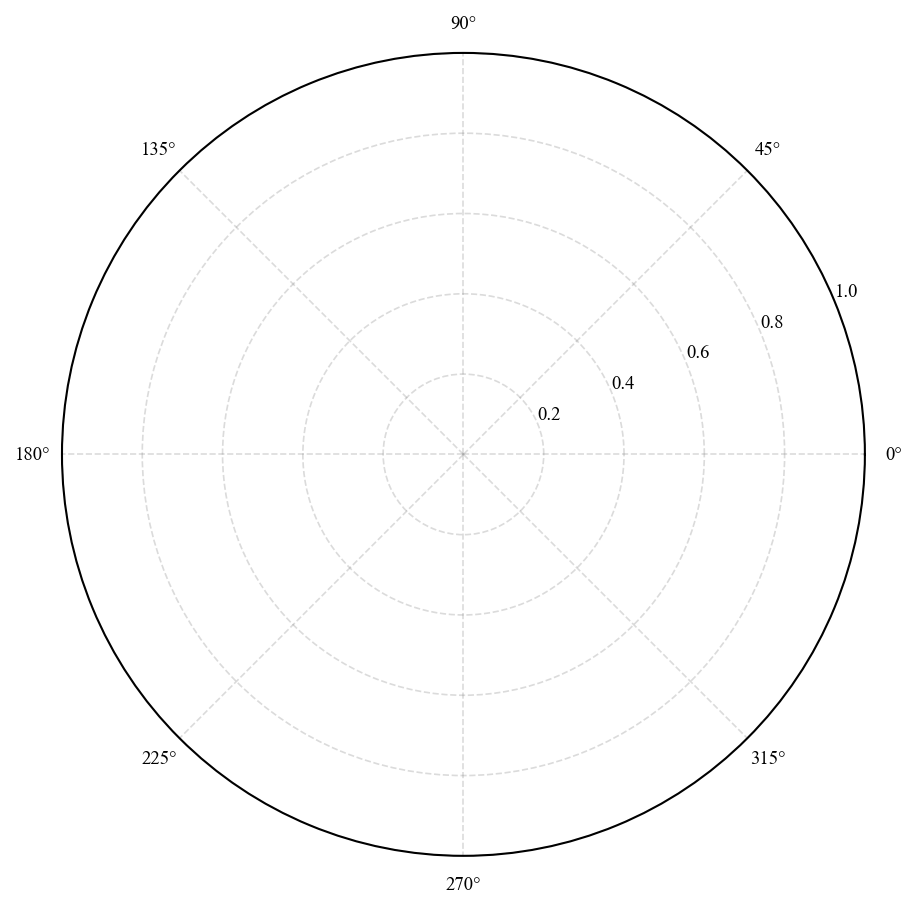

In [98]:
metric_radar  = ['chamfer', 'stretch', 'shear', 'contact', 'energy']
labels_radar  = ['Chamfer', 'Stretch', 'Shear', 'Contact', 'Total energy']
N_ax = len(metric_radar)

angles  = np.linspace(0, 2 * np.pi, N_ax, endpoint=False).tolist()
angles += angles[:1]   # close the loop

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True), constrained_layout=True)
fig.patch.set_facecolor('#FFFFFF')
ax.set_facecolor('#FFFFFF')

for method in ['elliptical', 'complex']:
    label  = LABELS[method]
    values = [df_summary.loc[label, f'{k}_mean'] for k in metric_radar]
    baseline = [df_summary.loc[LABELS['elliptical'], f'{k}_mean'] for k in metric_radar]
    normed   = [v / b if b > 1e-12 else 0 for v, b in zip(values, baseline)]
    normed  += normed[:1]

    ax.plot(angles, normed,
            color=COLORS[method], lw=LW[method], label=label)
    ax.fill(angles, normed,
            color=COLORS[method], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=9, fontweight='bold')
ax.set_yticks([0.25, 0.5, 0.75, 1.0, 1.25])
ax.set_yticklabels(['0.25×', '0.5×', '0.75×', '1× (baseline)', '1.25×'], fontsize=7)
ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='#888888')
ax.xaxis.grid(True, linestyle='--', alpha=0.3, color='#888888')
ax.set_title('Normalised mean performance (smaller is better)',
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), frameon=False)

fig.savefig(os.path.join(FIG_DIR, 'radar_chart.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'radar_chart.png'))
plt.show()

---

**Figures saved to:** `data/outputs/notebook_figures/`
- `convergence_curves.{pdf,png}` — loss curves for all experiments
- `chamfer_curves.{pdf,png}` — chamfer distance convergence
- `bar_metrics.{pdf,png}` — final metric bar charts
- `relative_improvement.{pdf,png}` — % improvement of complex over elliptical
- `final_shapes.{pdf,png}` — side-by-side deployed configurations
- `radar_chart.{pdf,png}` — normalised aggregate performance
- `summary_table.{csv,tex}` — quantitative comparison table